**Code Simulation des données (uniroot)**

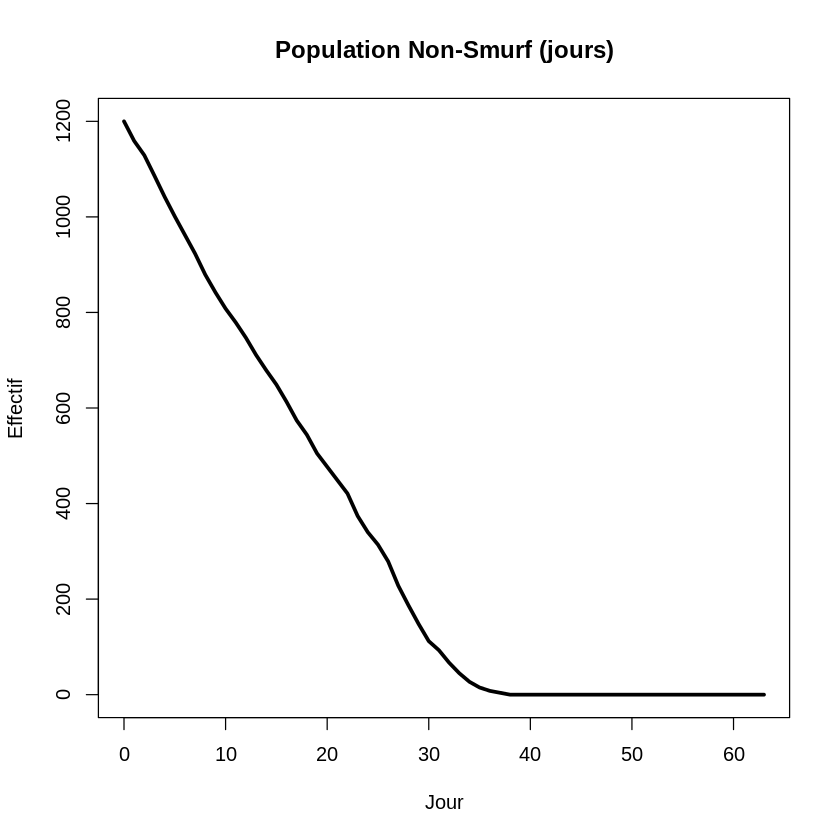

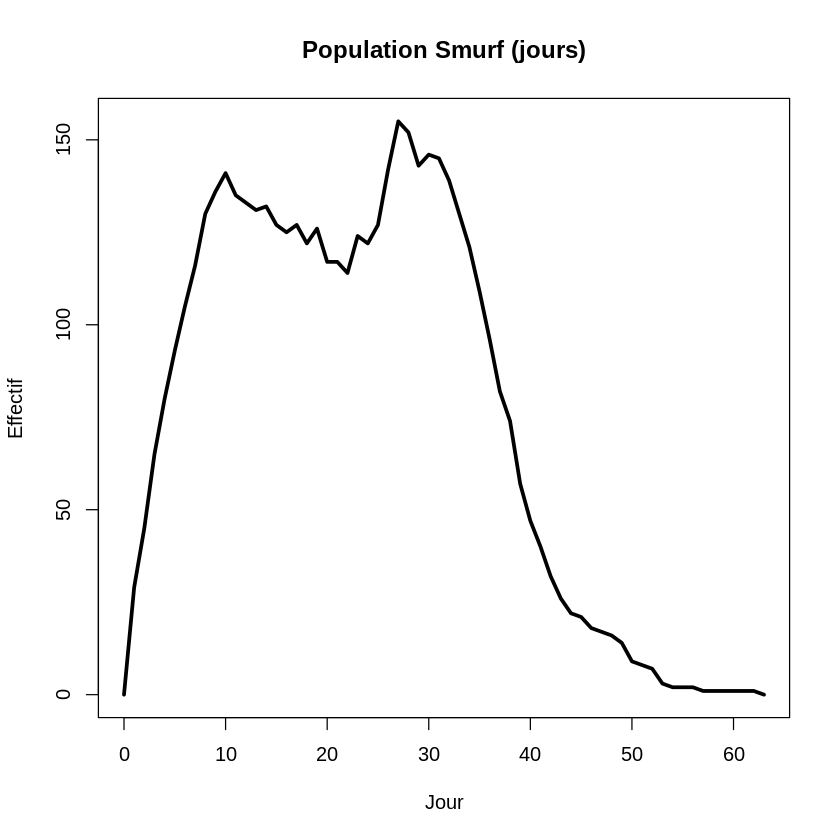

,Fly,T_NS,T_S,T_DEATH
,<int>,<dbl>,<dbl>,<dbl>
1,1,14.33447,2.61994896,16.95442
2,2,10.00621,15.57054019,25.57675
3,3,12.85268,17.59769147,30.45038
4,4,22.44105,1.41645062,23.85750
5,5,10.26430,0.47277111,10.73707
6,6,26.18547,0.01227986,26.19775


,Jour,NonSmurf,Smurf,Dead
,<int>,<dbl>,<dbl>,<dbl>
1,0,1200,0,0
2,1,1159,29,12
3,2,1129,45,26
4,3,1086,65,49
5,4,1042,80,78
6,5,1001,93,106


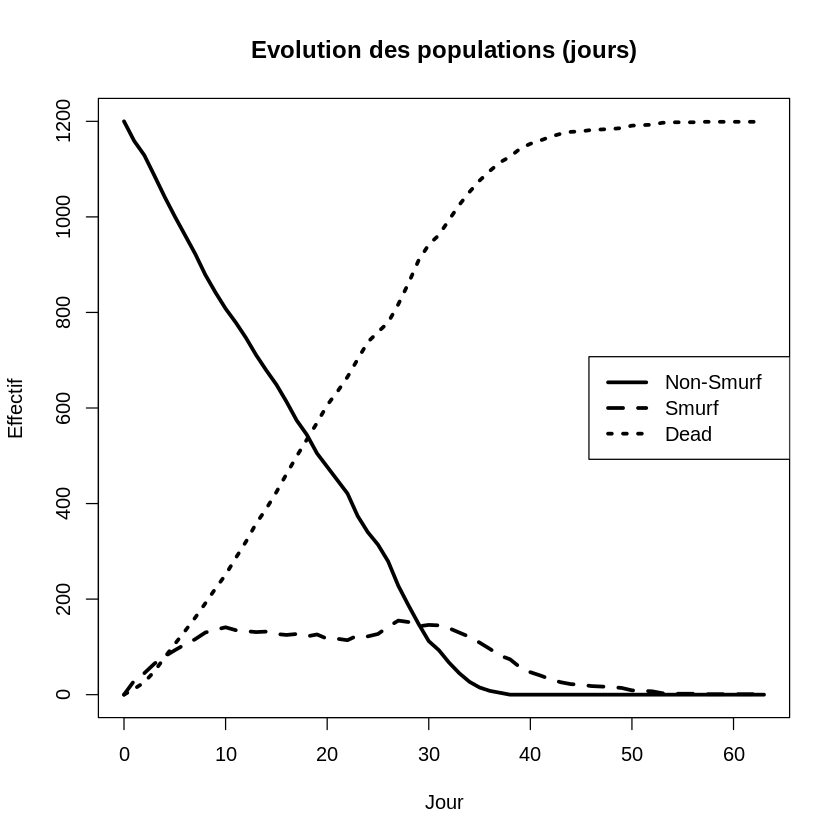

In [2]:
#################################################
# PARAMETRES
#################################################

N0 <- 1200

# Non-Smurf -> Smurf
F <- 0.00146805570484498
G <- 7.54476439893396e-05
H <- 0.0066373291015625

# Mortalité Smurf
K1 <- 0.0073127348748547
K2 <- 0.0293175232889041
D  <- 0.06715

#################################################
# 1. TEMPS NON-SMURF (EN HEURES)
#################################################

rNonSmurf <- function(n,F,G,H){

  U <- runif(n)

  times <- sapply(U,function(u){

    uniroot(

      function(t){

        F*t +
          (G/H)*(exp(H*t)-1) +
          log(u)

      },

      #--------------- La 2ème méthode pour 208 jours
      #  interval=c(0,5000)
      #---------------

      interval=c(0,100000)

    )$root

  })

  return(times/24)
}

#################################################
# 2. TEMPS SMURF (EN HEURES)
#################################################

rSmurf <- function(n,K1,K2,D){

  U <- runif(n)

  times <- sapply(U,function(u){

    f <- function(a){

      K1*a +
      (K2/D)*(1-exp(-D*a)) +
      log(u)

    }


    uniroot(f,c(0,100000))$root
  })

  return(times/24)

}

#################################################
# 3. SIMULATION COMPLETE (EN JOURS)
#################################################

simuler_populations <- function(
  N0,
  F,G,H,
  K1,K2,D
){

  T_NS <- rNonSmurf(N0,F,G,H)
  T_S  <- rSmurf(N0,K1,K2,D)

  T_DEATH <- T_NS + T_S

  flies <- data.frame(
    Fly = 1:N0,
    T_NS = T_NS,
    T_S = T_S,
    T_DEATH = T_DEATH
  )

  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  N_non_smurf <- numeric(length(time))
  N_smurf     <- numeric(length(time))
  N_dead      <- numeric(length(time))

  for(k in seq_along(time)){

    t <- time[k]

    N_non_smurf[k] <- sum(T_NS > t)

    N_smurf[k] <- sum(
      T_NS <= t &
      T_DEATH > t
    )

    N_dead[k] <- sum(T_DEATH <= t)
  }

  daily_pop <- data.frame(
    Day = time,
    NonSmurf = N_non_smurf,
    Smurf = N_smurf,
    Dead = N_dead
  )

  return(list(
    flies = flies,
    daily_pop = daily_pop,
    time_day = time,
    NonSmurf = N_non_smurf,
    Smurf = N_smurf,
    Dead = N_dead,
    T_NS = T_NS,
    T_S = T_S,
    T_DEATH = T_DEATH
  ))
}


#################################################
# 7. COURBES EN JOURS
#################################################
simuler= simuler_populations(
  N0,
  F,G,H,
  K1,K2,D
)

plot(
  simuler$time_day,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  xlab="Jour",
  ylab="Effectif",
  main="Population Non-Smurf (jours)"
)

plot(
  simuler$time_day,
  simuler$Smurf,
  type="l",
  lwd=3,
  xlab="Jour",
  ylab="Effectif",
  main="Population Smurf (jours)"
)

plot(
  simuler$time_day,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  ylim=c(0,N0),
  xlab="Jour",
  ylab="Effectif",
  main="Evolution des populations (jours)"
)

lines(simuler$time_day, simuler$Smurf, lwd=3, lty=2)
lines(simuler$time_day, simuler$Dead, lwd=3, lty=3)

legend(
  "right",
  legend=c("Non-Smurf","Smurf","Dead"),
  lty=c(1,2,3),
  lwd=3
)

#################################################
# 9. AFFICHAGE
#################################################

head(simuler$flies)
head(data.frame(
  Jour = simuler$time_day,
  NonSmurf = simuler$NonSmurf,
  Smurf = simuler$Smurf,
  Dead = simuler$Dead
))

**Code simulation des données (Newton-Raphson)**

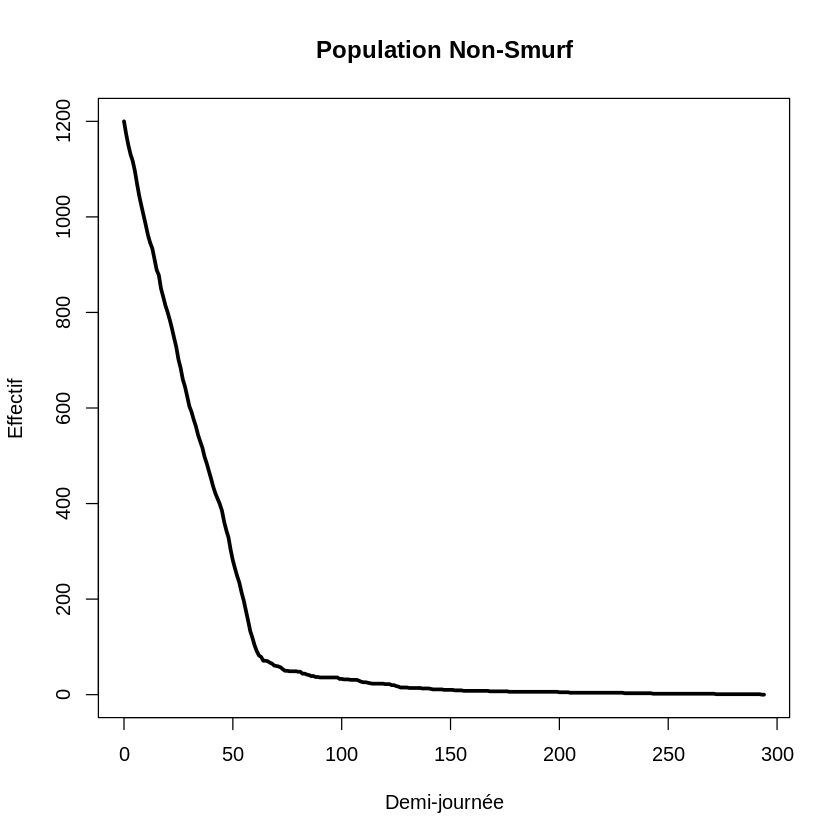

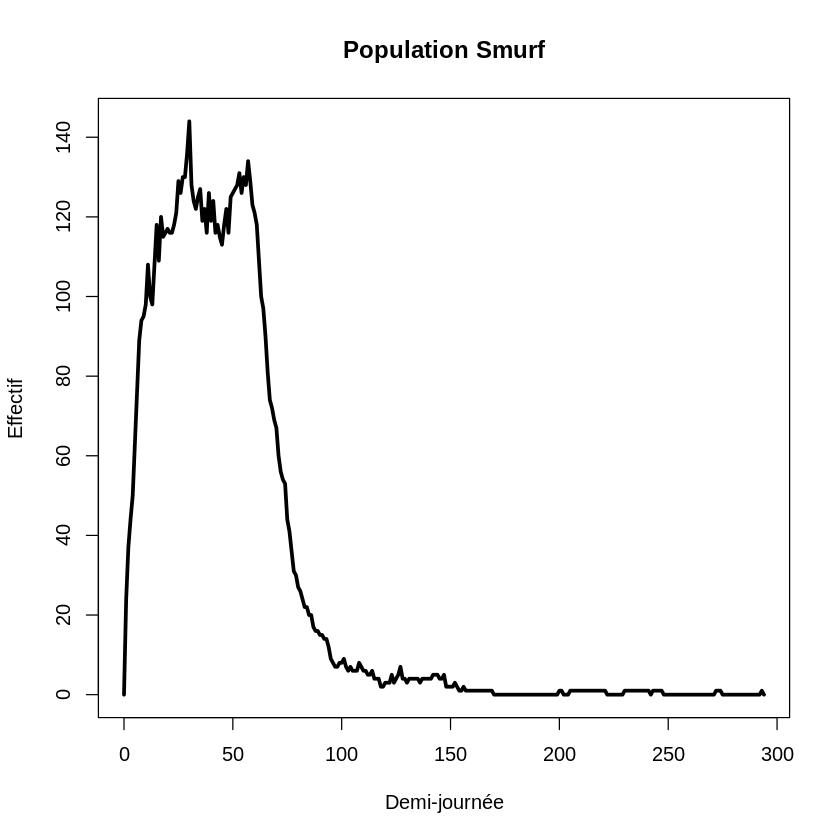

,Fly,T_NS,T_S,T_DEATH
,<int>,<dbl>,<dbl>,<dbl>
1,1,28.25802,0.6645571,28.92258
2,2,37.98059,39.9548193,77.93541
3,3,25.38155,0.1176794,25.49923
4,4,38.73645,1.0250463,39.76149
5,5,24.95620,19.2745980,44.23080
6,6,38.12075,11.1458190,49.26657


,DemiJour,NonSmurf,Smurf,Dead
,<int>,<dbl>,<dbl>,<dbl>
1,0,1200,0,0
2,1,1173,24,3
3,2,1150,37,13
4,3,1131,44,25
5,4,1117,50,33
6,5,1096,63,41


===== MOYENNES EN JOURS =====
Non-Smurf : 17.25962 
Smurf     : 3.606441 
Death     : 20.86606 


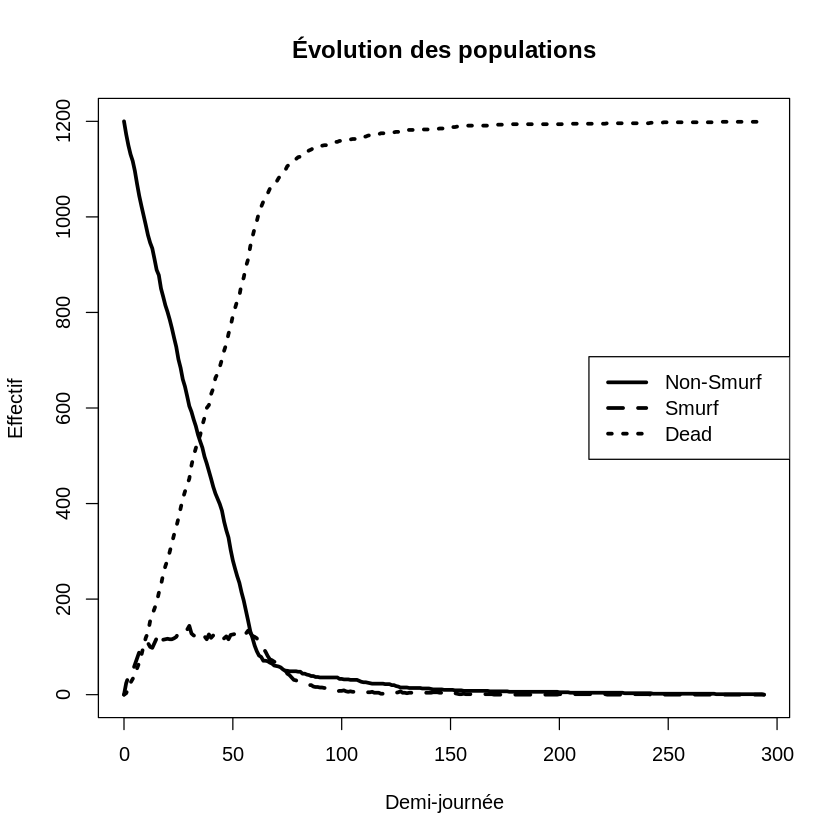

In [ ]:
#################################################
# PARAMETRES
#################################################

N0 <- 1200

# Non-Smurf -> Smurf
F <- 0.00146805570484498
G <- 7.54476439893396e-05
H <- 0.0066373291015625

# Mortalité Smurf
K1 <- 0.0073127348748547
K2 <- 0.0293175232889041
D  <- 0.06715


#################################################
# 1. SOLVEURS NEWTON-RAPHSON
#################################################

solve_NS1 <- function(u, F, G, H){

  f <- function(t){
    F*t + (G/H)*(exp(H*t)-1) + log(u)
  }

  fprime <- function(t){
    F + G*exp(H*t)
  }

  t <- 1

  for(i in 1:8){
    t <- t - f(t)/fprime(t)
    if(t < 0) t <- 0
  }

  return(t)
}


solve_S1 <- function(u, K1, K2, D){

  f <- function(a){
    K1*a + (K2/D)*(1-exp(-D*a)) + log(u)
  }

  fprime <- function(a){
    K1 + K2*exp(-D*a)
  }

  a <- 1

  for(i in 1:8){
    a <- a - f(a)/fprime(a)
    if(a < 0) a <- 0
  }

  return(a)
}


#################################################
# 2. TEMPS NON-SMURF (DEMI-JOURNÉES)
#################################################

rNonSmurf1 <- function(n, F, G, H){

  U <- runif(n)
  times <- numeric(n)

  for(i in 1:n){
    times[i] <- solve_NS1(U[i], F, G, H)
  }

  return(times / 12)
}


#################################################
# 3. TEMPS SMURF (DEMI-JOURNÉES)
#################################################

rSmurf1 <- function(n, K1, K2, D){

  U <- runif(n)
  times <- numeric(n)

  for(i in 1:n){
    times[i] <- solve_S1(U[i], K1, K2, D)
  }

  return(times / 12)
}


#################################################
# 4. SIMULATION COMPLETE
#################################################

simuler_populations <- function(N0, F,G,H, K1,K2,D){

  T_NS <- rNonSmurf1(N0, F, G, H)
  T_S  <- rSmurf1(N0, K1, K2, D)

  T_DEATH <- T_NS + T_S

  flies <- data.frame(
    Fly = 1:N0,
    T_NS = T_NS,
    T_S = T_S,
    T_DEATH = T_DEATH
  )

  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  N_non_smurf <- numeric(length(time))
  N_smurf <- numeric(length(time))
  N_dead <- numeric(length(time))

  for(k in seq_along(time)){

    t <- time[k]

    N_non_smurf[k] <- sum(T_NS > t)

    N_smurf[k] <- sum(T_NS <= t & T_DEATH > t)

    N_dead[k] <- sum(T_DEATH <= t)
  }

  list(
    flies = flies,
    time = time,
    NonSmurf = N_non_smurf,
    Smurf = N_smurf,
    Dead = N_dead
  )
}


#################################################
# 5. EXECUTION
#################################################

simuler <- simuler_populations(
  N0,
  F,G,H,
  K1,K2,D
)


#################################################
# 6. COURBES (DEMI-JOURNÉES)
#################################################

plot(
  simuler$time,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  xlab="Demi-journée",
  ylab="Effectif",
  main="Population Non-Smurf"
)

plot(
  simuler$time,
  simuler$Smurf,
  type="l",
  lwd=3,
  xlab="Demi-journée",
  ylab="Effectif",
  main="Population Smurf"
)

plot(
  simuler$time,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  ylim=c(0,N0),
  xlab="Demi-journée",
  ylab="Effectif",
  main="Évolution des populations"
)

lines(simuler$time, simuler$Smurf, lwd=3, lty=2)
lines(simuler$time, simuler$Dead, lwd=3, lty=3)

legend(
  "right",
  legend=c("Non-Smurf","Smurf","Dead"),
  lty=c(1,2,3),
  lwd=3
)


#################################################
# 7. AFFICHAGE
#################################################

head(simuler$flies)

head(data.frame(
  DemiJour = simuler$time,
  NonSmurf = simuler$NonSmurf,
  Smurf = simuler$Smurf,
  Dead = simuler$Dead
))

#################################################
# 8. MOYENNES DES TEMPS (EN JOURS)
#################################################

T_NS_jours <- simuler$flies$T_NS / 2
T_S_jours <- simuler$flies$T_S / 2
T_DEATH_jours <- simuler$flies$T_DEATH / 2

cat("===== MOYENNES EN JOURS =====\n")

cat("Non-Smurf :", mean(T_NS_jours), "\n")
cat("Smurf     :", mean(T_S_jours), "\n")
cat("Death     :", mean(T_DEATH_jours), "\n")

**Code simulation (méthode IBPM)**

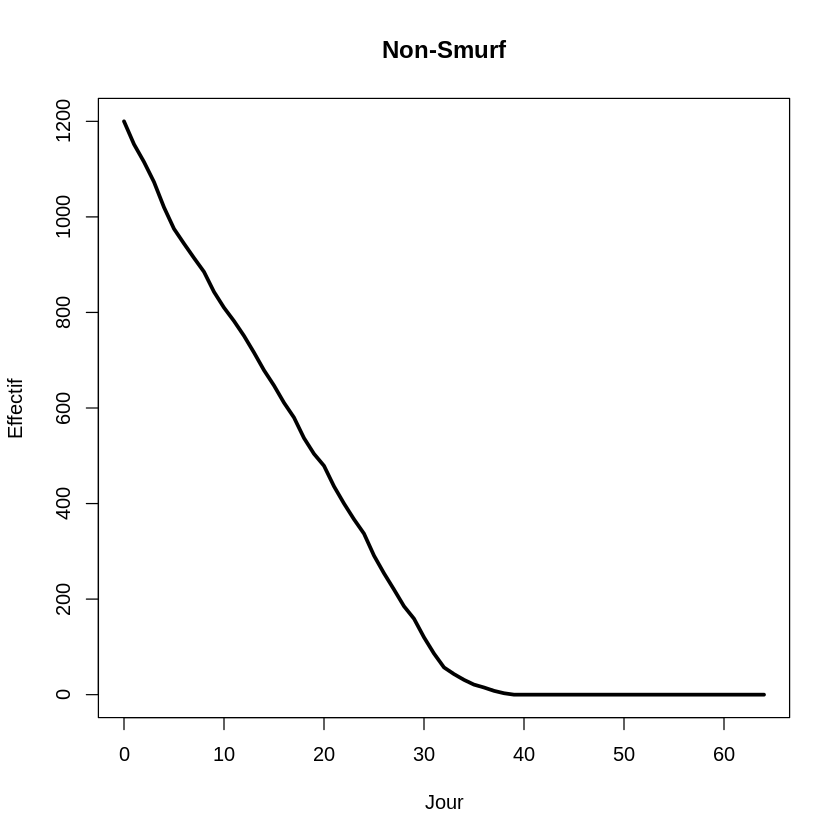

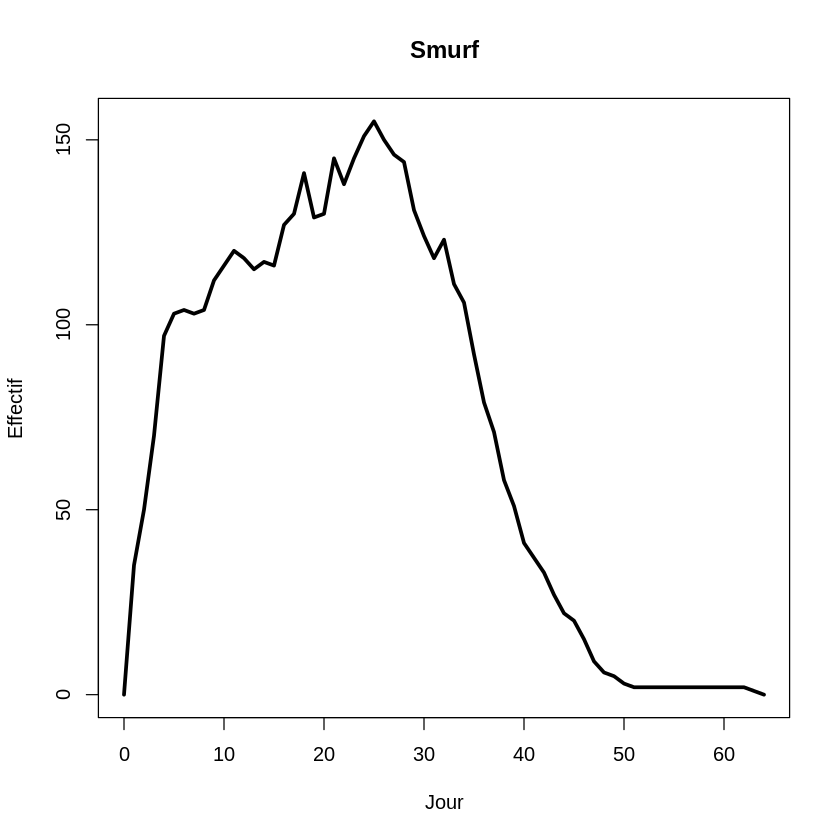

[1] 29.09130 27.52464 13.10448 11.46006 17.86541 20.46245

[1] 17.5488368  4.2995844  0.6438851  6.4527318 16.8540625  0.6580075

[1] 46.64014 31.82422 13.74836 17.91279 34.71947 21.12046

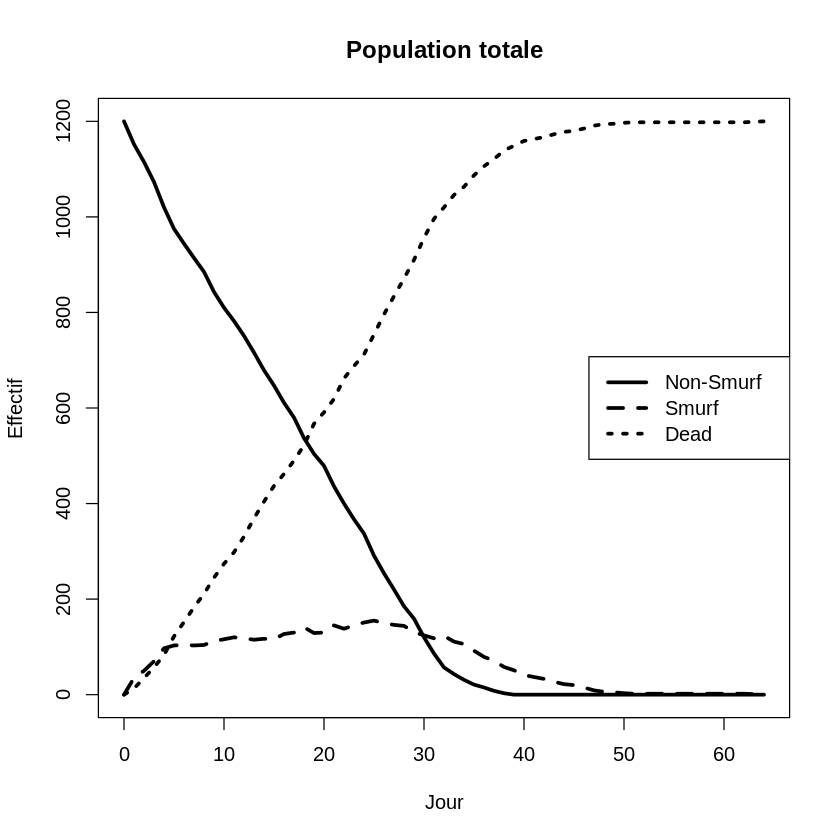

In [ ]:
#################################################
# 0. INITIALISATION
#################################################

rm(list = ls())

#################################################
# 1. MODELE GLOBAL
#################################################

create_model <- function(N0){
  list(N0 = N0)
}

#################################################
# 2. SOLVEUR OPTIMISE
#################################################

solve_times <- function(U, f, interval=c(0,100000)){

  vapply(U, function(u){
    uniroot(function(t) f(t) + log(u), interval)$root
  }, numeric(1))

}

#################################################
# 3. LOI NON-SMURF
#################################################

rNonSmurf <- function(n, F, G, H){

  U <- runif(n)

  f <- function(t){
    F*t + (G/H)*(exp(H*t) - 1)
  }

  solve_times(U, f) / 24    #/12 pour une prise de donnée sur 12 heures
}

#################################################
# 4. LOI SMURF
#################################################

rSmurf <- function(n, K1, K2, D){

  U <- runif(n)

  f <- function(t){
    K1*t + (K2/D)*(1 - exp(-D*t))
  }

  solve_times(U, f) / 24    #/12 pour une prise de donnée sur 12 heures
}

#################################################
# 5. SIMULATION COMPLETE
#################################################

simulate_system <- function(model, params){

  N0 <- model$N0

  F  <- params["F"]
  G  <- params["G"]
  H  <- params["H"]

  K1 <- params["K1"]
  K2 <- params["K2"]
  D  <- params["D"]

  # générations des temps individuels
  T_NS <- rNonSmurf(N0, F, G, H)
  T_S  <- rSmurf(N0, K1, K2, D)

  T_DEATH <- T_NS + T_S

  # grille temporelle
  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  # populations
  NonSmurf <- vapply(time, function(t) sum(T_NS > t), numeric(1))
  Smurf    <- vapply(time, function(t) sum(T_NS <= t & T_DEATH > t), numeric(1))
  Dead     <- vapply(time, function(t) sum(T_DEATH <= t), numeric(1))

  list(
    time = time,
    NonSmurf = NonSmurf,
    Smurf = Smurf,
    Dead = Dead,
    raw = list(T_NS=T_NS, T_S=T_S, T_DEATH=T_DEATH)
  )
}

#################################################
# 6. CACHE
#################################################

cache <- new.env()

simulate_cached <- function(model, params){

  key <- paste(round(params, 6), collapse = "_")

  if(exists(key, cache)){
    return(cache[[key]])
  }

  res <- simulate_system(model, params)
  cache[[key]] <- res

  res
}

#################################################
# 7. WRAPPER ABC
#################################################

abc_step <- function(model, params){
  simulate_cached(model, params)
}

#################################################
# 8. PARAMETRES DE TEST
#################################################

N0 <- 1200

params <- c(
  F  = 0.00146805570484498,
  G  = 7.54476439893396e-05,
  H  = 0.0066373291015625,
  K1 = 0.0073127348748547,
  K2 = 0.0293175232889041,
  D  = 0.06715
)

#################################################
# 9. EXECUTION SIMULATION
#################################################

model <- create_model(N0)

sim <- simulate_system(model, params)

#################################################
# 10. PLOTS
#################################################

plot(sim$time, sim$NonSmurf,
     type="l", lwd=3,
     xlab="Jour", ylab="Effectif",
     main="Non-Smurf")

plot(sim$time, sim$Smurf,
     type="l", lwd=3,
     xlab="Jour", ylab="Effectif",
     main="Smurf")

plot(sim$time, sim$NonSmurf,
     type="l", lwd=3,
     ylim=c(0, N0),
     xlab="Jour", ylab="Effectif",
     main="Population totale")

lines(sim$time, sim$Smurf, lwd=3, lty=2)
lines(sim$time, sim$Dead, lwd=3, lty=3)

legend("right",
       legend=c("Non-Smurf","Smurf","Dead"),
       lty=c(1,2,3),
       lwd=3)

#################################################
# 11. OUTPUT DATA
#################################################

head(sim$raw$T_NS)
head(sim$raw$T_S)
head(sim$raw$T_DEATH)

In [ ]:
#################################################
# VERIFICATION NON-SMURF
#################################################

png("verification_non_smurf.png", width=800, height=600)

plot(
  ecdf(simuler$T_NS),
  main = "Fonction de répartition Non-Smurf",
  xlab = "Temps (jours)",
  ylab = "F(t)",
  lwd = 3,
  col = "blue"
)

F_NS <- function(t){

  1 - exp(
    -F*(24*t) -
    (G/H)*(exp(H*(24*t))-1)
  )

}

x <- seq(
  0,
  max(simuler$T_NS),
  length.out = 1000
)

lines(
  x,
  F_NS(x),
  lwd = 3,
  lty = 2,
  col = "red"
)

legend(
  "bottomright",
  legend = c("Empirique","Théorique"),
  col = c("blue","red"),
  lwd = 3,
  lty = c(1,2)
)

dev.off()

#################################################
# VERIFICATION SMURF
#################################################


png("verification_smurf.png", width=800, height=600)

plot(
  ecdf(simuler$T_S),
  main = "Fonction de répartition Smurf",
  xlab = "Temps (jours)",
  ylab = "F(t)",
  lwd = 3,
  col = "blue"
)

F_S <- function(t){

  a <- 24*t

  1 - exp(
    -K1*a -
    (K2/D)*(1-exp(-D*a))
  )

}

x <- seq(
  0,
  max(simuler$T_S),
  length.out = 1000
)

lines(
  x,
  F_S(x),
  lwd = 3,
  lty = 2,
  col = "red"
)

legend(
  "bottomright",
  legend = c("Empirique","Théorique"),
  col = c("blue","red"),
  lwd = 3,
  lty = c(1,2)
)
dev.off()


ERROR: Error: object 'simuler' not found


#**Simulation avec l'ABC-SMC**

Nous allons utiliser le code **Code simulation (méthode IBPM)** pour la simulation des populations

In [ ]:
# installation du package nécessaire pour utiliser ABC-SMC
install.packages("tmvtnorm")
library(tmvtnorm)

# 3 fonctions utilisées dans l'ABC-SMC

rK <- function(mean, sigma){
	return(rtmvnorm(1,mean=mean, sigma=sigma, lower=lm.low, upper=lm.upp))
}

H_indicator <- function(x) as.numeric(x>0)

prior.non.zero<-function(par){
	prod(sapply(1:3, function(a) H_indicator(par[a]-lm.low[a])* H_indicator(lm.upp[a]-par[a])))
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**On fixe d'abord K1,K2,D pour estimer les 3 premiers paramètres F , G , H avec une prise de donnée toute les  24 heures**

In [ ]:
calc_distance_2 <- function(D, D_star){

  n <- max( length(D$NonSmurf) , length(D_star$NonSmurf))


  NS <- c(D$NonSmurf, rep(0, n - length(D$NonSmurf)))
  NS_star <- c(D_star$NonSmurf, rep(0, n - length(D_star$NonSmurf)))


  # Distance
  dist_2 <- sqrt(sum((NS - NS_star)^2))

  return(dist_2)
}

In [ ]:
calc_distance_3 <- function(D, D_star){

  n <- max( length(D$NonSmurf) , length(D_star$NonSmurf))

  # Compléter NonSmurf
  NS <- c(D$NonSmurf, rep(0, n - length(D$NonSmurf)))
  NS_star <- c(D_star$NonSmurf, rep(0, n - length(D_star$NonSmurf)))

  # Compléter Smurf
  S <- c(D$Smurf, rep(0, n - length(D$Smurf)))
  S_star <- c(D_star$Smurf, rep(0, n - length(D_star$Smurf)))

  # Distance
  dist_3 <- sqrt(sum((NS - NS_star)^2)) + sqrt(sum((S - S_star)^2))

  return(dist_3)
}

In [ ]:

##### paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####


#création du modèle
params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


#Algo ABC-SMC

N = 1000 # nombres de particules
epsilon_A <-   c(2000,1000,900,700,500,350) # tolérance pour la distance d2 par défaut
# à changer en (2000,1000,900,800,700,500) pour la distance d3


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  F=F_obs*0.1 ,
  G=G_obs*0.1,
  H=H_obs*0.1
)
lm.upp <- c(
  F=F_obs*1.9 ,
  G=G_obs*1.9,
  H=H_obs*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    tentatives <- 0
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            F <- runif(1, min=lm.low[1], max=lm.upp[1])
            G <-runif(1, min=lm.low[2], max=lm.upp[2])
            H <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            F <-par[1]
            G <- par[2]
            H <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(F , G , H))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F, G=G, H=H, K1=K1_obs, K2=K2_obs, D=D_obs_par)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_2(D_obs, D_star)  # la distance est d2 par défaut
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(F , G , H)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("F" , "G" , "H" )
res.new <- as.data.frame(res.new)

dist N=  541.3346 
[1] "Generation: 1, particle: 2"
dist N=  551.9301 
[1] "Generation: 1, particle: 3"
dist N=  772.6076 
[1] "Generation: 1, particle: 4"
dist N=  298.6298 
[1] "Generation: 1, particle: 5"
dist N=  989.1162 
[1] "Generation: 1, particle: 6"
dist N=  821.9706 
[1] "Generation: 1, particle: 7"
dist N=  2635.62 
[1] "Generation: 1, particle: 8"
dist N=  1145.244 
[1] "Generation: 1, particle: 9"
dist N=  2400.601 
[1] "Generation: 1, particle: 10"
dist N=  1413.699 
[1] "Generation: 1, particle: 11"
dist N=  996.39 
[1] "Generation: 1, particle: 12"
dist N=  1130.267 
[1] "Generation: 1, particle: 13"
dist N=  853.6011 
[1] "Generation: 1, particle: 14"
dist N=  1009.51 
[1] "Generation: 1, particle: 15"
dist N=  1236.624 
[1] "Generation: 1, particle: 16"
dist N=  1287.151 
[1] "Generation: 1, particle: 17"
dist N=  451.5638 
[1] "Generation: 1, particle: 18"
dist N=  1220.82 
[1] "Generation: 1, particle: 19"
dist N=  1772.554 
[1] "Generation: 1, particle: 20"
dist N

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [1]:
estimated_F = res.new[,1]
estimated_G = res.new[,2]
estimated_H = res.new[,3]




mean_F = mean(estimated_F)
mean_G = mean(estimated_G)
mean_H = mean(estimated_H)


err_F = abs(mean_F - F_obs)/F_obs
err_G = abs(mean_G - G_obs)/G_obs
err_H = abs(mean_H - H_obs)/H_obs




interv_credible_F = quantile(estimated_F, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de F
interv_credible_G = quantile(estimated_G, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de G
interv_credible_H = quantile(estimated_H, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de H

cat("Pour le paramètre F :\n")
cat("  Moyenne des estimations :", round(mean_F, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_F), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_F[1], 6), ", ", round(interv_credible_F[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_F[2], 6) - round(interv_credible_F[1], 6), "\n")
cat("  Erreur relative : ", err_F , "\n\n")


cat("Pour le paramètre G :\n")
cat("  Moyenne des estimations :", round(mean_G, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_G), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_G[1], 6), ", ", round(interv_credible_G[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_G[2], 6) - round(interv_credible_G[1], 6), "\n")
cat("  Erreur relative : ", err_G , "\n\n")

cat("Pour le paramètre H :\n")
cat("  Moyenne des estimations :", round(mean_H, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_H), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_H[1], 6), ", ", round(interv_credible_H[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_H[2], 6) - round(interv_credible_H[1], 6), "\n")
cat("  Erreur relative : ", err_H , "\n\n")



ERROR: Error: object 'res.new' not found


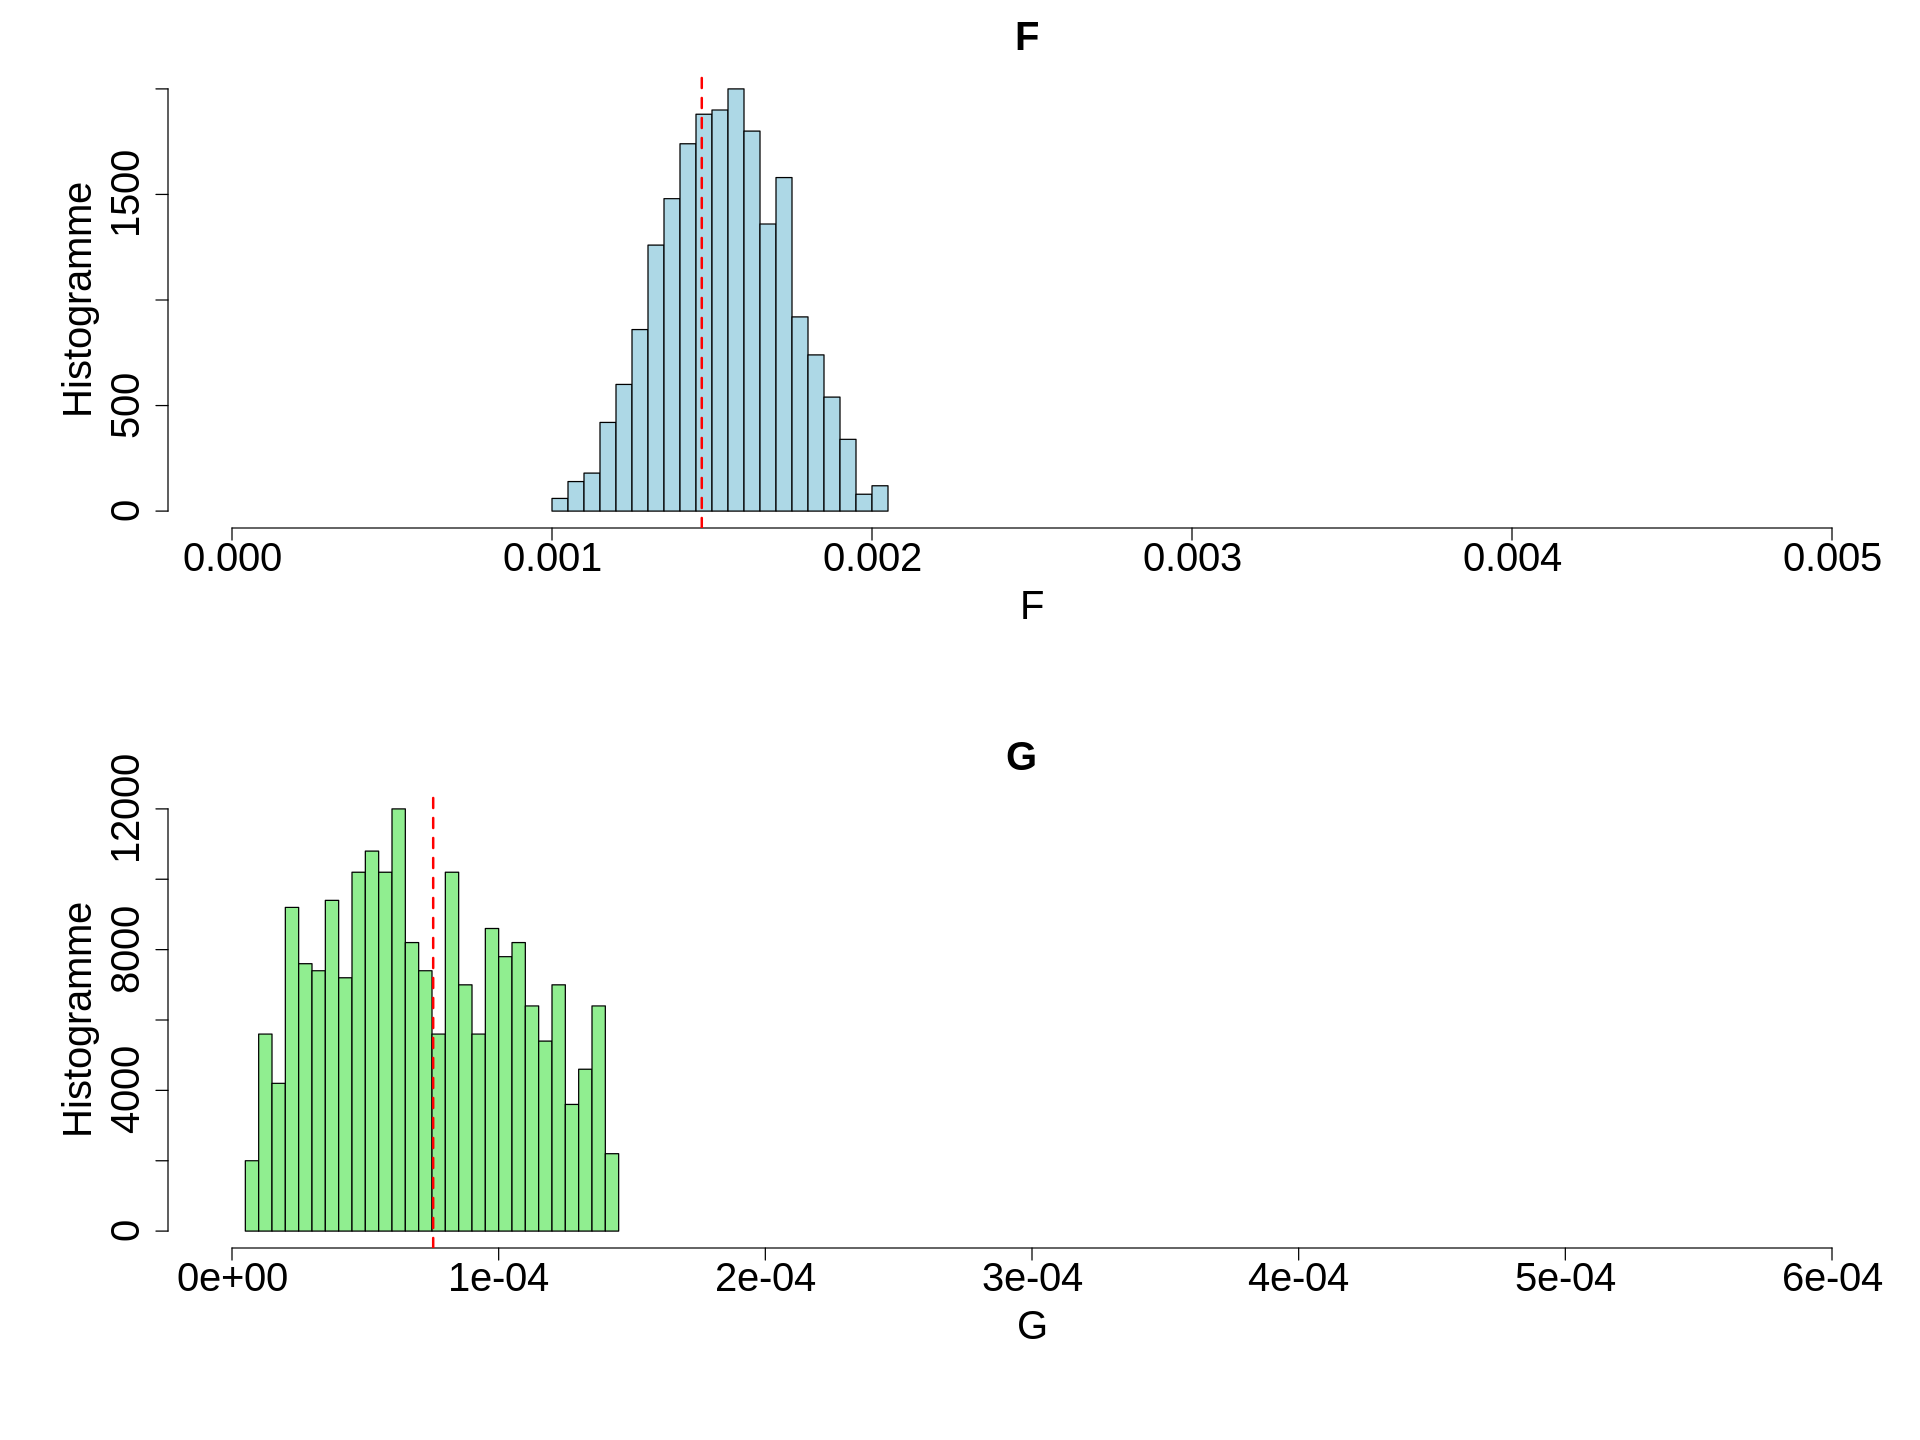

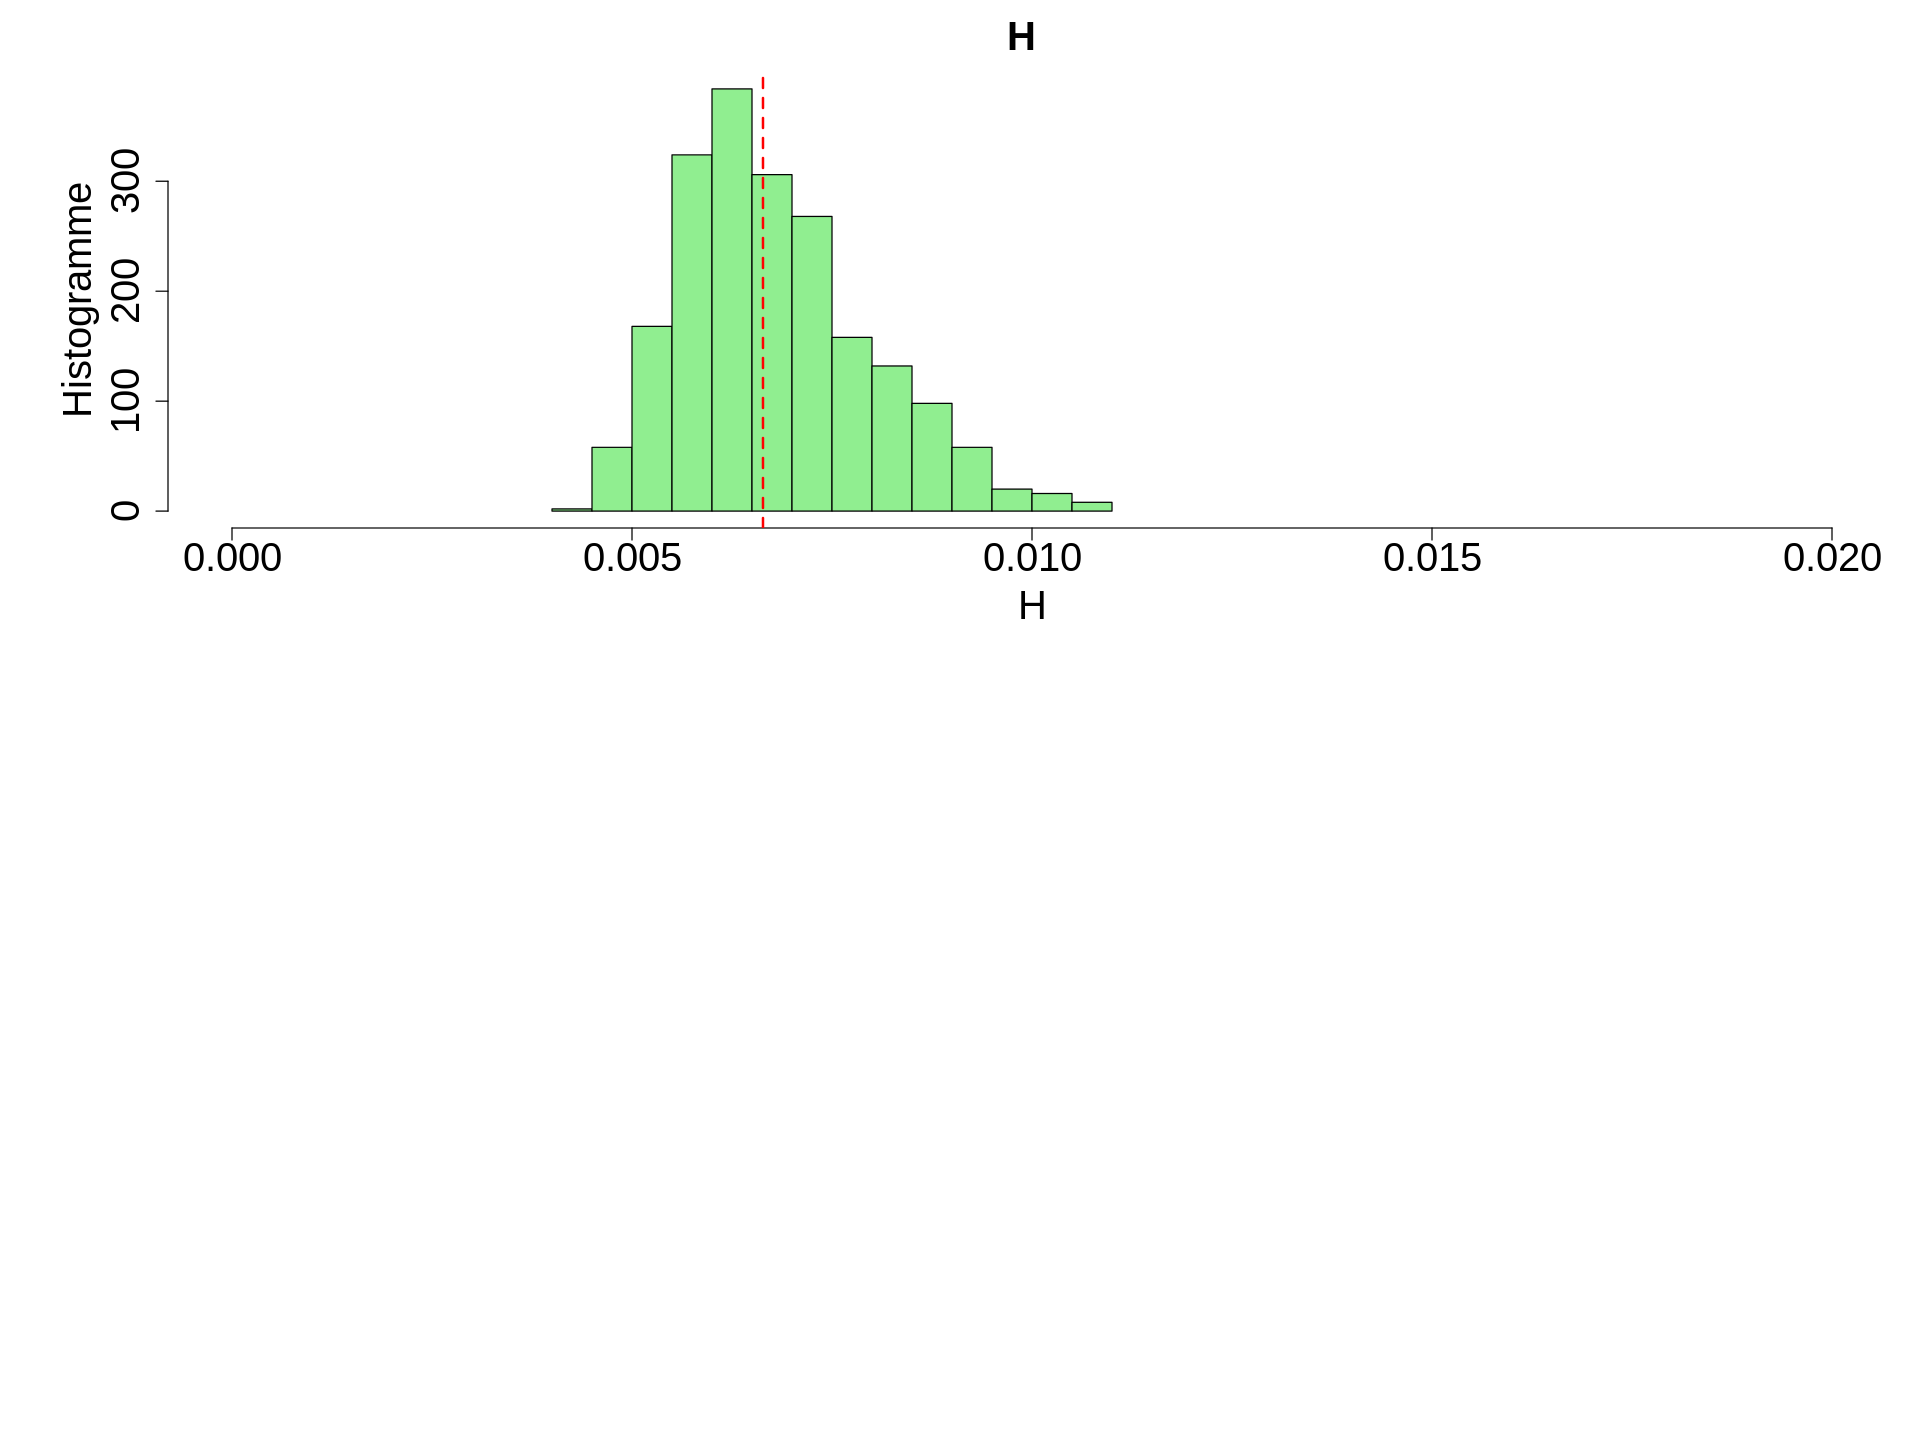

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME F
  # =================================================

  hist(
    res$F,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("F "),
    xlab = expression(F),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.005)
  )

  abline(
    v = 0.00146805570484498,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME G
  # =================================================

  hist(
    res$G,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "G  "),
    xlab = expression(G),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.0006)
  )

  abline(
    v = 7.54476439893396e-05 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME H
  # =================================================

  hist(
    res$H,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "H  " ),
    xlab = expression(H),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.02)
  )

  abline(
    v = 0.0066373291015625 ,
    col = "red",
    lwd = 2,
    lty = 2
  )


**Estimons les paramètres K1,K2,D en fixant F , G , H avec prise de donnée toute les 24 heures**

In [ ]:
calc_distance_1 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )



  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))

  dist_1 <- sqrt(sum((D1 - D1_star)^2))


  return(dist_1)
}

In [ ]:

##### paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####


#création du modèle
params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


#Algo ABC-SMC

N = 1000 # nombres de particules
epsilon_A <-   c(9000, 8000 , 6000 ,5000 ,4000,3000)


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  F=F_obs*0.1 ,
  G=G_obs*0.1,
  H=H_obs*0.1
)
lm.upp <- c(
  F=F_obs*1.9 ,
  G=G_obs*1.9,
  H=H_obs*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    tentatives <- 0
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            F <- runif(1, min=lm.low[1], max=lm.upp[1])
            G <-runif(1, min=lm.low[2], max=lm.upp[2])
            H <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            F <-par[1]
            G <- par[2]
            H <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(F , G , H))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F, G=G, H=H, K1=K1_obs, K2=K2_obs, D=D_obs_par)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_1(D_obs, D_star)  # la distance est d2 par défaut
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(F , G , H)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("F" , "G" , "H" )
res.new <- as.data.frame(res.new)

dist N=  804.8333 
[1] "Generation: 1, particle: 2"
dist N=  395.8739 
[1] "Generation: 1, particle: 3"
dist N=  441.6635 
[1] "Generation: 1, particle: 4"
dist N=  637.6208 
[1] "Generation: 1, particle: 5"
dist N=  277.9107 
[1] "Generation: 1, particle: 6"
dist N=  217.4923 
[1] "Generation: 1, particle: 7"
dist N=  221.3473 
[1] "Generation: 1, particle: 8"
dist N=  283.8401 
[1] "Generation: 1, particle: 9"
dist N=  693.8692 
[1] "Generation: 1, particle: 10"
dist N=  428.1822 
[1] "Generation: 1, particle: 11"
dist N=  488.594 
[1] "Generation: 1, particle: 12"
dist N=  892.5653 
[1] "Generation: 1, particle: 13"
dist N=  240.1569 
[1] "Generation: 1, particle: 14"
dist N=  200.936 
[1] "Generation: 1, particle: 15"
dist N=  585.7901 
[1] "Generation: 1, particle: 16"
dist N=  235.959 
[1] "Generation: 1, particle: 17"
dist N=  222.1363 
[1] "Generation: 1, particle: 18"
dist N=  572.7191 
[1] "Generation: 1, particle: 19"
dist N=  627.3824 
[1] "Generation: 1, particle: 20"
dist

On va refaire le code spécialement pour la distance d4 car il y a deux tolérances

In [ ]:
calc_distance_4 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )
  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))
  dist_1 <- sqrt(sum((D1 - D1_star)^2))



propor = D$Smurf[17]/(D$Dead[17] + D$Smurf[17])
propor_star = D_star$Smurf[17]/(D_star$Dead[17] + D_star$Smurf[17])

dist_4 = abs(propor - propor_star)



  return(c(dist_1 ,dist_4))
}

In [ ]:
# paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715


params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


N = 1000 # nb de particule

epsilon_A <-   c(9000 , 8000 , 7000 , 6000 , 5000 , 4000)
epsilon_B <-   c(0.2 , 0.15 , 0.10 , 0.08 , 0.06 , 0.05)

# Nb de génération
Gene <- length(epsilon_A)


# Nb de simulation pour les paramètres
n <- 1

#  borne des priors
lm.low <- c(
  K1=K1_obs*0.1 ,
  K2=K2_obs*0.1,
  D=D_obs_par*0.1
)
lm.upp <- c(
  K1=K1_obs*1.9 ,
  K2=K2_obs*1.9,
  D=D_obs_par*1.9  )


#simuler_populations( N0,F,G,H,K1,K2,D)

# Matrice vide pour stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteur vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)


for(g in 1:Gene){


    i<-1
    tentatives <- 0
    while(i <= N){ # tant que le nb de particules acceptées est inférieur à N

        if(g==1){
                # loi des distributions priors
            K1 <- runif(1, min=lm.low[1], max=lm.upp[1])
            K2<- runif(1, min=lm.low[2], max=lm.upp[2])
            D <-runif(1, min=lm.low[3], max=lm.upp[3])
        } else {
            #  selection des particules depuis la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            K1 <-par[1]
            K2 <-par[2]
            D <-par[3]
        }
        #  test si le prior est nulle
        if(prior.non.zero(c( K1 , K2 , D))) {

                m<-0
                distance <-matrix(ncol=2,nrow=n)

                for(j in 1:n){
                    params = c(F=F_obs, G=G_obs, H=H_obs, K1=K1, K2=K2, D=D)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_4(D_obs, D_star)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist[1] <= epsilon_A[g] & calc.dist[2]<= epsilon_B[g] ){ # si les deux distances sont inferieur à leurs tolérances
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des résultats
                    res.new[i,]<-c( K1 , K2 , D)
                # calcul desq poids
                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c( "K1" , "K2" , "D")
res.new <- as.data.frame(res.new)

**Piste envisageable pour diminuer l'erreur de K1** : Pour essayer de diminuer l'erreur relative de K1, on sait que les informations par rapport aux variables aléatoires à estimer sont dans les premières heures alors, on peut se dire qu'au lieu de prélever les données toutes les 24 heures ce que l'on faisait jusqu'à maintenant, on prélève les données toutes les 12 heures (Il faut changer dans le code simulation la /24 par /12).

In [ ]:
calc_distance_1 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )



  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))

  dist_1 <- sqrt(sum((D1 - D1_star)^2))


  return(dist_1)
}

In [ ]:

##### paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####


#création du modèle
params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


#Algo ABC-SMC

N = 1000 # nombres de particules

epsilon_A <-   c(10000, 9000 , 8000 ,7000 , 6000 , 5000)


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  F=F_obs*0.1 ,
  G=G_obs*0.1,
  H=H_obs*0.1
)
lm.upp <- c(
  F=F_obs*1.9 ,
  G=G_obs*1.9,
  H=H_obs*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    tentatives <- 0
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            F <- runif(1, min=lm.low[1], max=lm.upp[1])
            G <-runif(1, min=lm.low[2], max=lm.upp[2])
            H <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            F <-par[1]
            G <- par[2]
            H <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(F , G , H))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F, G=G, H=H, K1=K1_obs, K2=K2_obs, D=D_obs_par)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_1(D_obs, D_star)  # la distance est d2 par défaut
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(F , G , H)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("F" , "G" , "H" )
res.new <- as.data.frame(res.new)

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715



estimated_K1 = res.new[,1]
estimated_K2 = res.new[,2]
estimated_D = res.new[,3]


mean_K1 = mean(estimated_K1)
mean_K2 = mean(estimated_K2)
mean_D = mean(estimated_D)


interv_credible_K1 = quantile(estimated_K1, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de K1
interv_credible_K2 = quantile(estimated_K2, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de K2
interv_credible_D = quantile(estimated_D, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de D

err_K1 = abs(mean_K1 - K1_obs)/K1_obs
err_K2 = abs(mean_K2 - K2_obs)/K2_obs
err_D = abs(mean_D - D_obs_par)/D_obs_par


cat("Pour le paramètre K1 :\n")
cat("  Moyenne des estimations :", round(mean_K1, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_K1), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_K1[1], 6), ", ", round(interv_credible_K1[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_K1[2], 6) - round(interv_credible_K1[1], 6), "\n")
cat("  Erreur relative : ", err_K1 , "\n\n")



cat("Pour le paramètre K2 :\n")
cat("  Moyenne des estimations :", round(mean_K2, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_K2), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_K2[1], 6), ", ", round(interv_credible_K2[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_K2[2], 6) - round(interv_credible_K2[1], 6), "\n")
cat("  Erreur relative : ", err_K2 , "\n\n")


cat("Pour le paramètre D :\n")
cat("  Moyenne des estimations :", round(mean_D, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_D), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_D[1], 6), ", ", round(interv_credible_D[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_D[2], 6) - round(interv_credible_D[1], 6), "\n")
cat("  Erreur relative : ", err_D , "\n\n")


Pour le paramètre K1 :
  Moyenne des estimations : 0.008402 
  Variance des estimations : 3.574e-06 
  Intervalle de crédibilité à 95% : [ 0.004697 ,  0.012093 ]
  Largeur de l'intervalle :  0.007396 

Pour le paramètre K2 :
  Moyenne des estimations : 0.02592061 
  Variance des estimations : 0.000197773 
  Intervalle de crédibilité à 95% : [ 0.004293 ,  0.053293 ]
  Largeur de l'intervalle :  0.049 

Pour le paramètre D :
  Moyenne des estimations : 0.077666 
  Variance des estimations : 0.000842426 
  Intervalle de crédibilité à 95% : [ 0.021338 ,  0.123962 ]
  Largeur de l'intervalle :  0.102624 



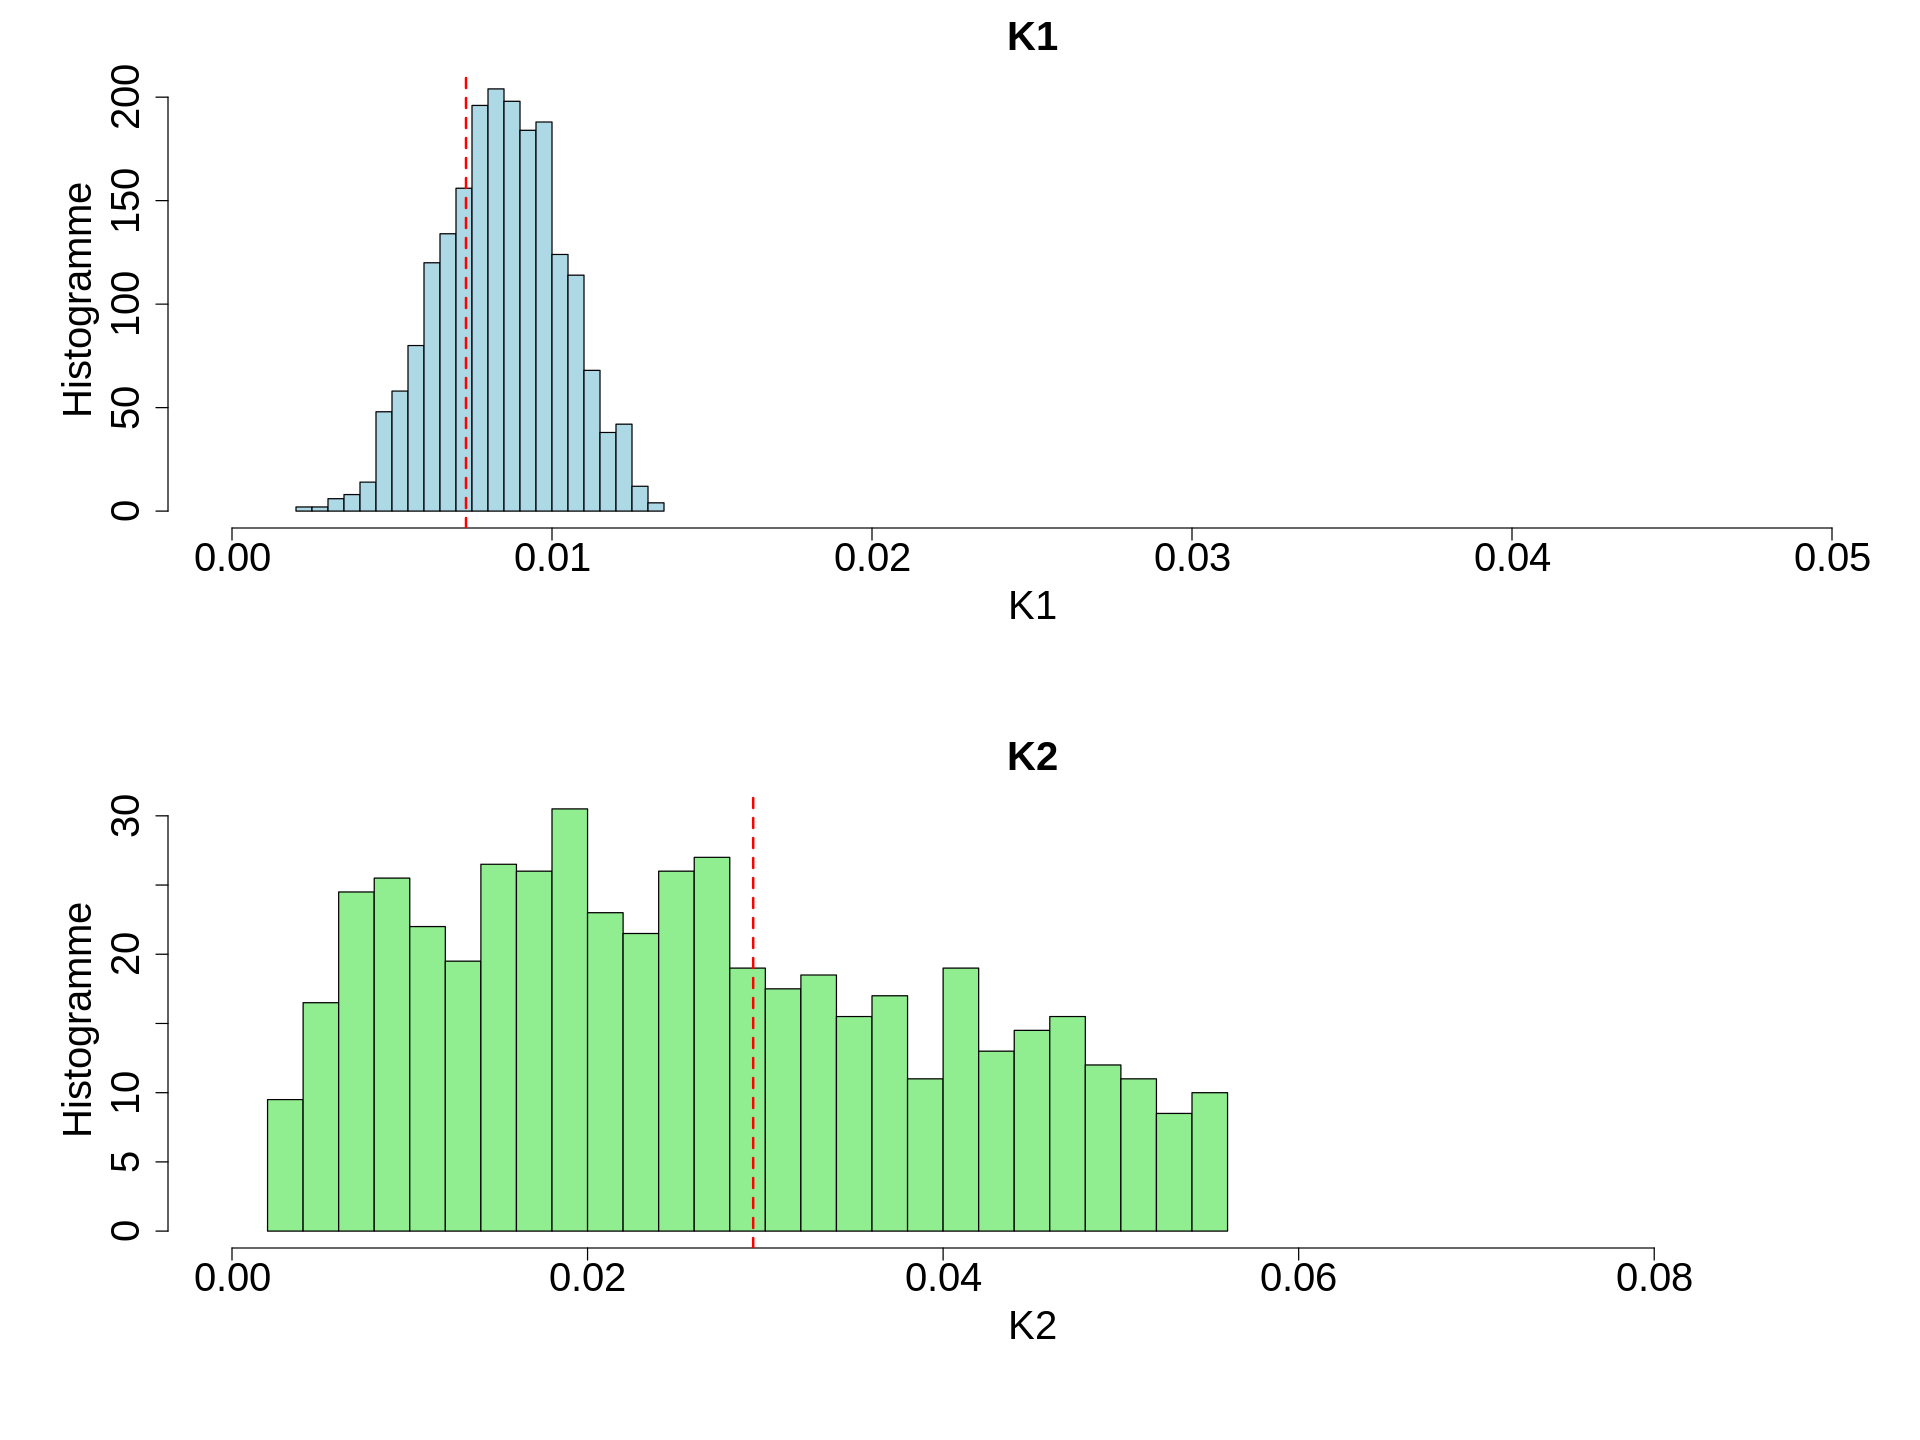

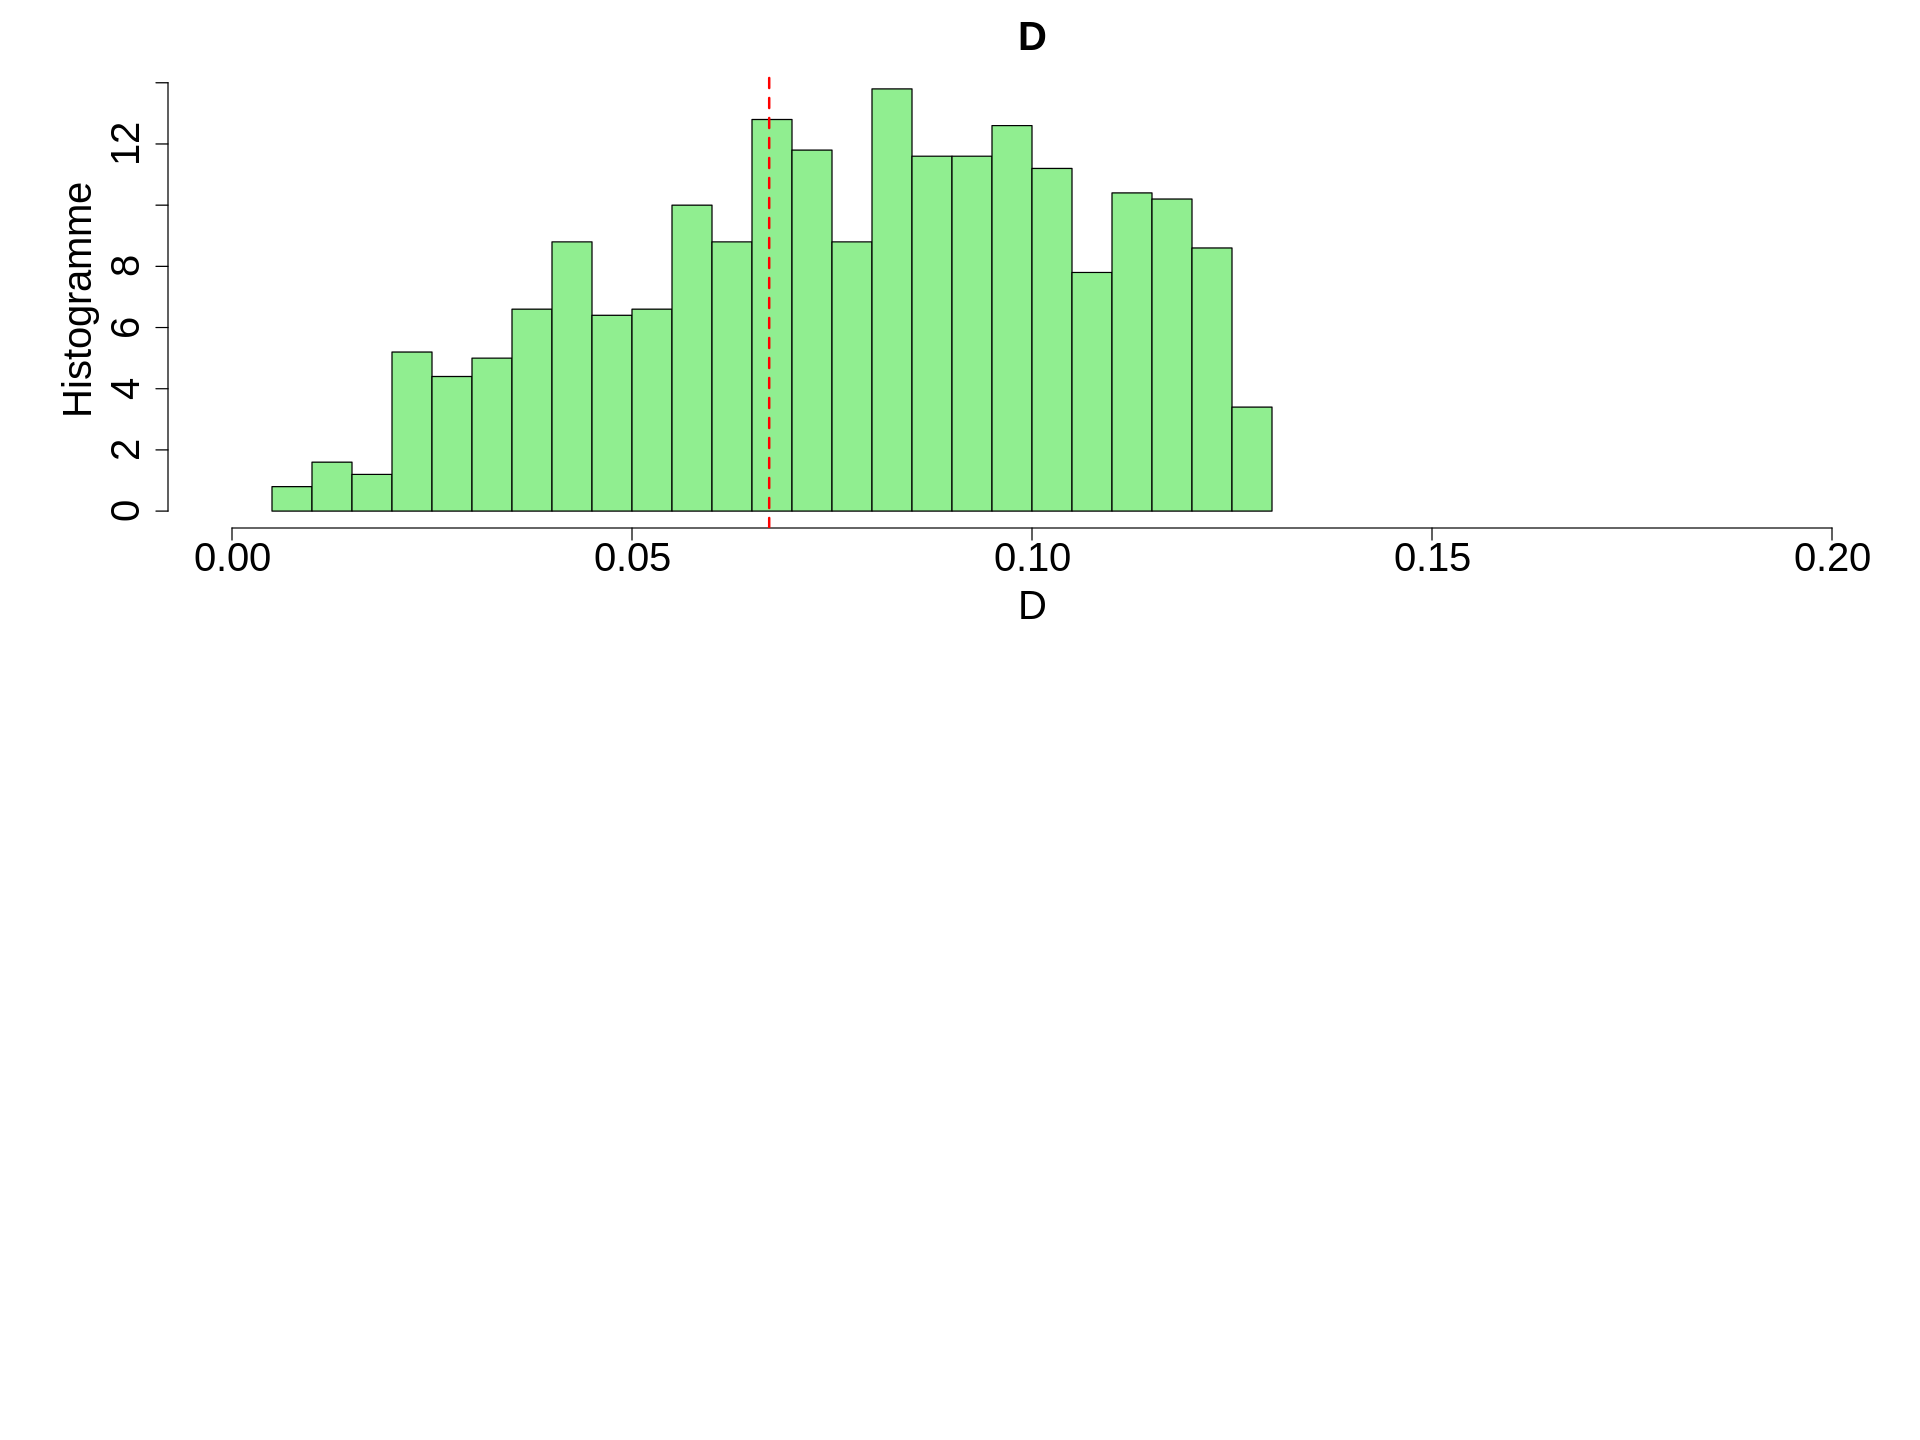

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME K1
  # =================================================

  hist(
    res[,1],
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("K1"),
    xlab = expression(K1),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.05)
  )

  abline(
    v = 0.0073127348748547,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME K2
  # =================================================

  hist(
    res[,2],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "K2"),
    xlab = expression(K2),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.09)
  )

  abline(
    v = 0.0293175232889041 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME D
  # =================================================

  hist(
    res[,3],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "D" ),
    xlab = expression(D),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.2)
  )

  abline(
    v = 0.06715 ,
    col = "red",
    lwd = 2,
    lty = 2
  )
